# Examen Bewegingen: Nokken
## Specificaties (Opgave 50)
De te ontwerpen nok moet volgende heffing kunnen realiseren :
- van 10° tot 65° : +10 mm
- van 95° tot 210° : +40 mm
- van 210° tot 350° : -50 mm 

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 5 kg en 0.062, terwijl het mechanisme volgende statische krachten moet uitoefenen:
- van 30° tot 110° : een konstante druk-kracht van 450 N
- van 110° tot 190° : een konstante druk-kracht van 950 N
- van 230° tot 300° : een lineair afnemende trek-kracht van 300 N tot 0 N 

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.10 sec.

In [5]:
# utility functions
from matplotlib import pyplot as plt
import numpy as np
import numpy.fft as fourier
import ipywidgets as widgets
from ipywidgets import interact, FloatLogSlider

def applySegments(F_func,values):
    # values is a list of nested tuples: [((startIdx, endIdx), value), ...]
    # value can be a single number (constant force) or a tuple (startValue, endValue) for linear interpolation
    for segment in values:
        interval, value = segment[0], segment[1]
        startIdx, endIdx = interval
        if isinstance(value, tuple):
            startValue, endValue = value
            F_func[startIdx:endIdx] = np.linspace(startValue, endValue, endIdx - startIdx)
        else:
            F_func[startIdx:endIdx] = value            
    return F_func

def plotMotionLaw(t,lift,vel,acc):
    fig, ax = plt.subplots(nrows=2,ncols=2,constrained_layout=True)
    fig.suptitle("Lift")
    
    ax[0,0].plot(t, lift)
    ax[0,0].set_ylabel("Lift [mm]")
    ax[0,0].set_xlabel('Theta [deg]')
    ax[0,0].set_xlim([0,360])
    
    ax[1,0].plot(t, vel)
    ax[1,0].set_ylabel("Snelheid [mm]/s")
    ax[1,0].set_xlabel('Theta [deg]')
    ax[1,0].set_xlim([0,360])
    
    ax[0,1].plot(t, acc)
    ax[0,1].set_ylabel("Versnelling [mm/s^2]")
    ax[0,1].set_xlabel('Theta [deg]')
    ax[0,1].set_xlim([0,360])

    # FFT van de versnelling
    N = len(acc)
    fft_acc = np.fft.fft(acc)
    amplitudes = np.abs(fft_acc) / N   # eenzijdig spectrum
    harmonics = np.arange(N // 2)      # harmonische nummers (0 = DC, 1 = grondtoon, ...)

    ax[1,1].stem(harmonics, 2 * amplitudes[:N // 2])
    ax[1,1].set_ylabel("Amplitude [mm/s²]")
    ax[1,1].set_xlabel("Harmonische [-]")
    ax[1,1].set_xlim([0, 40])            # toon eerste 20 harmonischen
    ax[1,1].set_title("FFT versnelling")

def plotForces(t,forces,variable,labels,title="Krachten"):
    N = len(forces)
    fig, ax = plt.subplots(nrows=N,ncols=1,constrained_layout=True)
    fig.suptitle(title)

    for i, force in enumerate(forces):
        ax[i].plot(t, force)
        ax[i].set_ylabel(labels[i])
        ax[i].set_xlabel(variable)
        ax[i].set_xlim([np.min(t), np.max(t)])
    
    plt.show()

def undercutting(R0, lift, vel_ang, acc_ang, R_r):
    R_tot = R0 + lift
    rho = (R_tot**2 + vel_ang**2)**(3/2) / (R_tot**2 + 2 * vel_ang**2 - R_tot * acc_ang)
    return np.min(rho) < R_r

def generateCamProfile(R0, ex, R_r, F_func, k_v, c, m, gamma, motionLaw, g=9.81):
    theta_rad = motionLaw.theta_deg * np.pi / 180
    lift = motionLaw.lift
    vel = motionLaw.vel
    acc = motionLaw.acc
    omega = motionLaw.n * 2 * np.pi / 60 # angular velocity in rad/s

    height = np.sqrt(R0**2 - ex**2) + lift
    R_pitch = np.sqrt(height**2 + ex**2)
    alpha = np.arctan((vel/omega + ex) / height) # angle of attack in radians
    # print(alpha)µ

    assert np.max(np.abs(alpha)) < np.pi/6, 'The angle of attack should be less than 30 degrees (increase R0 or change ex)'
    assert not undercutting(R0, lift, vel/omega, acc/omega**2, R_r), 'Undercutting occurs (increase R0 or decrease R_r)'

    psi = theta_rad - np.arcsin(ex / R_pitch)
    pitch_profile = np.array([R_pitch * np.cos(psi), R_pitch * np.sin(psi)])
    cam_profile = np.array([pitch_profile[0] - R_r * np.cos(theta_rad - alpha), pitch_profile[1] - R_r * np.sin(theta_rad - alpha)])


    F_y = F_func + k_v * lift + c * vel + m/1000 * acc + m * g * np.cos(gamma*np.pi/180)
    F_v0 = max(0,-min(F_y)*1.01)
    F_y += F_v0
    assert np.min(F_y) > 0,              'The contact force should be positive for all angles (increase F_v0 or k_v)'
    forces = F_y * np.array([np.tan(alpha), np.ones(np.shape(F_y))])
    torque = (height * forces[0] - ex * forces[1]) / 1000

    return pitch_profile, cam_profile, forces, torque

def plotCamProfile(R0, ex, R_r, motionLaw, pitch_profile, cam_profile, arrows=0):
    theta_rad = motionLaw.theta_deg * np.pi / 180

    # steekcirkel
    x_ps = R0 * np.cos(theta_rad)
    y_ps = R0 * np.sin(theta_rad)

    # basiscirkel
    x_base = (R0 - R_r) * np.cos(theta_rad)
    y_base = (R0 - R_r) * np.sin(theta_rad)

    # excentriciteitssrickel
    x_ex = ex * np.cos(theta_rad)
    y_ex = ex * np.sin(theta_rad)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(cam_profile[0], cam_profile[1], 'b-', linewidth=2, label='Nokprofiel')
    ax.plot(pitch_profile[0], pitch_profile[1], 'b--', linewidth=2, label='Steekkromme')
    ax.plot(x_base, y_base, 'r-', linewidth=1, label='Basiscirkel')
    ax.plot(x_ps, y_ps, 'r--', linewidth=1, label='Steekcirkel')
    ax.plot(0, 0, 'k+', markersize=10)

    if arrows != 0:
        for i in np.linspace(0, len(theta_rad), arrows, endpoint=False, dtype=int):
            ax.annotate('',
                xy=(cam_profile[0][i], cam_profile[1][i]),
                xytext=(pitch_profile[0][i], pitch_profile[1][i]),
                arrowprops=dict(arrowstyle='->', color='green', lw=1))

    if ex != 0:
        ax.plot(x_ex, y_ex, color='gray', linestyle='-.', linewidth=0.5, label=f'Excentriciteit e={ex} mm')

    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title('Nokprofiel met volgrol')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# MotionLaw class
# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":
class MotionLaw:
    """Lift, velocity and acceleration profiles for a cam-follower system."""

    DWELL = 1
    POLY3 = 2
    HARMONIC = 3
    CYCLOID = 4
    POLY5 = 5
    POLY7 = 6

    def __init__(self, n, dtheta=0.5, range_theta=360):
        self.n = n
        self.dtheta = dtheta
        self.range_theta = range_theta
        self.omega = n * 6  # deg/s

        self.theta_deg = np.arange(0, range_theta, dtheta)
        self.lift = np.zeros_like(self.theta_deg)
        self.vel  = np.zeros_like(self.theta_deg)
        self.acc  = np.zeros_like(self.theta_deg)

        self.segments = []

    def addMotionSegment(self, startangle, endangle, startlift, endlift, motionlaw):
        """Add a segment to the motion law."""
        assert endangle > startangle, 'End angle should be greater than start angle'

        start_i = int(startangle / self.dtheta)
        end_i   = int(endangle / self.dtheta)
        beta    = endangle - startangle
        L0, L   = startlift, endlift - startlift
        x       = np.linspace(0, 1, end_i - start_i)
        wb      = self.omega / beta  # omega / beta factor

        if motionlaw == self.DWELL:
            assert L == 0, 'Startlift and endlift should be equal for a dwell'
            s, v, a = np.full_like(x, L0), np.zeros_like(x), np.zeros_like(x)

        elif motionlaw == self.POLY3:
            s = L0 + L * (3*x**2 - 2*x**3)
            v = L * wb * (6*x - 6*x**2)
            a = L * wb**2 * (6 - 12*x)

        elif motionlaw == self.HARMONIC:
            s = L0 + L * (1 - np.cos(np.pi * x)) / 2
            v = L * wb * np.pi/2 * np.sin(np.pi * x)
            a = L * wb**2 * np.pi**2/2 * np.cos(np.pi * x)

        elif motionlaw == self.CYCLOID:
            s = L0 + L * (x - np.sin(2*np.pi*x) / (2*np.pi))
            v = L * wb * (1 - np.cos(2*np.pi*x))
            a = L * wb**2 * 2*np.pi * np.sin(2*np.pi*x)

        elif motionlaw == self.POLY5:
            s = L0 + L * (6*x**5 - 15*x**4 + 10*x**3)
            v = L * wb * (30*x**4 - 60*x**3 + 30*x**2)
            a = L * wb**2 * (120*x**3 - 180*x**2 + 60*x)

        elif motionlaw == self.POLY7:
            s = L0 + L * (-20*x**7 + 70*x**6 - 84*x**5 + 35*x**4)
            v = L * wb * (-140*x**6 + 420*x**5 - 420*x**4 + 140*x**3)
            a = L * wb**2 * (-840*x**5 + 2100*x**4 - 1680*x**3 + 420*x**2)

        else:
            raise ValueError(f'Unknown motion law: {motionlaw}')

        self.lift[start_i:end_i] = s
        self.vel[start_i:end_i]  = v
        self.acc[start_i:end_i]  = a

        self.segments.append({
            'start': startangle, 'end': endangle,
            'L0': startlift, 'L1': endlift, 'law': motionlaw
        })
        return self

    def plot(self):
        """Plot lift, velocity and acceleration."""
        plotMotionLaw(self.theta_deg, self.lift, self.vel, self.acc)

def torque_with_flywheel(I_K, motionlaw, load_torque):
    N  = len(load_torque)
    dt = motionlaw.dtheta/motionlaw.omega
    wn = 2*np.pi*fourier.fftfreq(N, d=dt)
    return np.real(fourier.ifft(fourier.fft(load_torque)/(1 - (I_K)*wn**2)))

Er staat een minteken voor $\alpha$, wat niet het geval is bij de formule uit de les. Dit verschil komt door het teken van $\theta$ (relatief met de nok <-> relatief met de volger). 

Gemiddeld vermogen (gebaseerd op bewegingswet): 439.88 W
Dempingsverlies: 106.65 W


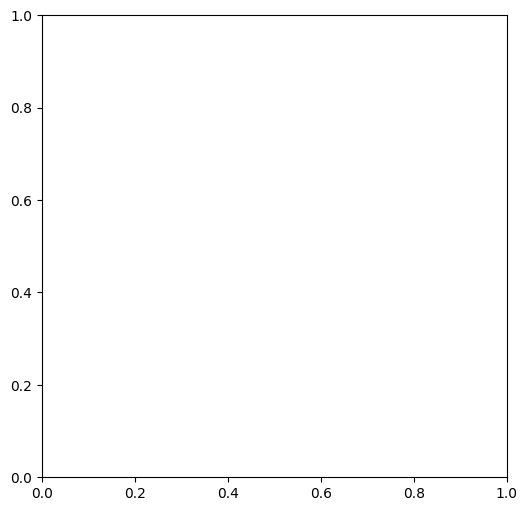

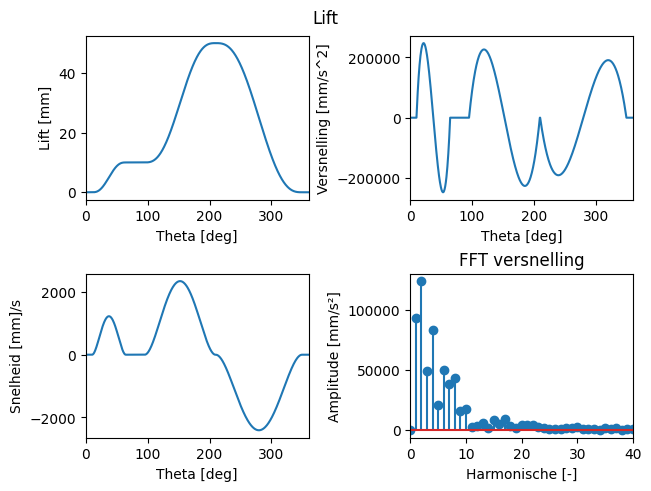

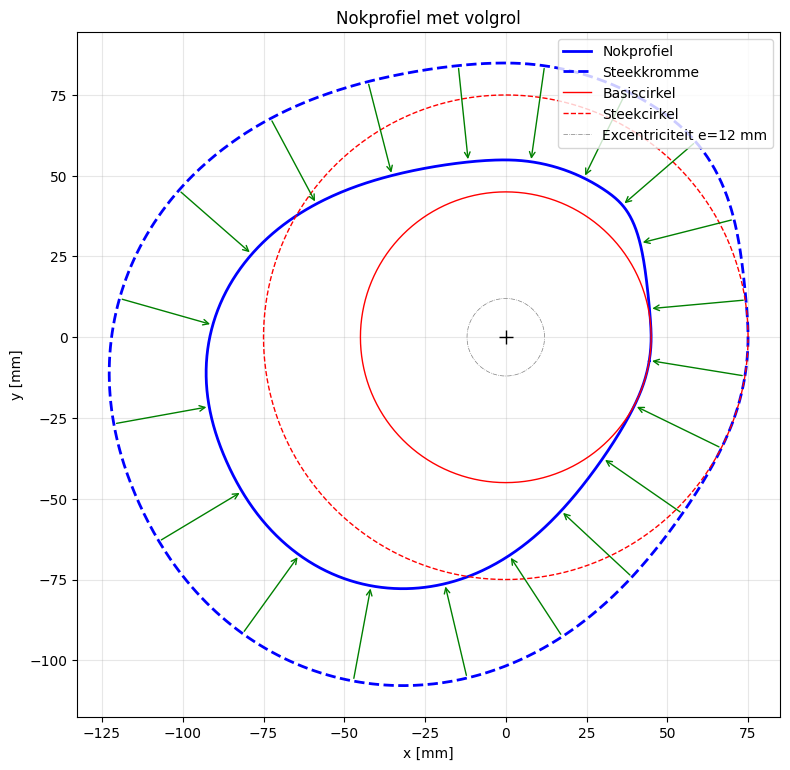

3448.188925945759


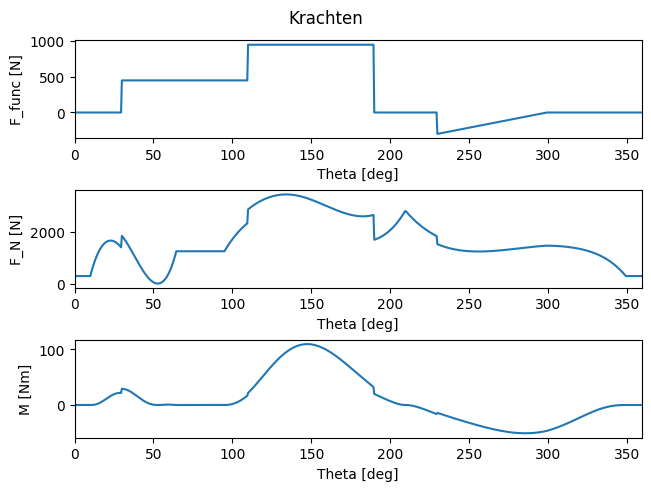

Gemiddeld vermogen (gebaseerd op lastkoppel): 545.67 W


In [6]:
gamma       = 0     # angle between lift and the gravity vector in degrees
m           = 5     # mass of the follower in kg
c           = 0.062 # damping coefficient in N/(mm/s)

n    = 600            # initial angular velocity in rpm
k_v  = 50             # spring tension force
R0   = 75             # base circle radius in mm
e    = 12             # excentricity in mm
R_r  = 30             # roller radius in mm

omega = n*2*np.pi/60

motionlaw = MotionLaw(n=n) 
motionlaw.addMotionSegment(startangle=10,   endangle=65,  startlift=0,  endlift=10, motionlaw=MotionLaw.POLY5)
motionlaw.addMotionSegment(startangle=65,  endangle=95, startlift=10, endlift=10, motionlaw=MotionLaw.DWELL)
motionlaw.addMotionSegment(startangle=95,  endangle=210, startlift=10, endlift=50, motionlaw=MotionLaw.POLY5)
motionlaw.addMotionSegment(startangle=210, endangle=350, startlift=50, endlift=0,  motionlaw=MotionLaw.POLY5)
motionlaw.plot()

F_func = np.zeros_like(motionlaw.theta_deg)          # function of angle-dependent forces in N
interval1 = (int(30/motionlaw.dtheta), int(110/motionlaw.dtheta))
interval2 = (int(110/motionlaw.dtheta), int(190/motionlaw.dtheta))
interval3 = (int(230/motionlaw.dtheta), int(300/motionlaw.dtheta))
applySegments(F_func, [(interval1, 450), (interval2, 950), (interval3, (-300, 0))])

P_av = np.sum(motionlaw.vel/1000 * F_func)*motionlaw.dtheta/360
P_loss = c*motionlaw.vel.std()**2 / 1000
print("Gemiddeld vermogen (gebaseerd op bewegingswet): %.2f W" % P_av)
print("Dempingsverlies: %.2f W" % P_loss)


pitch_profile, cam_profile, F_contact, M_load = generateCamProfile(R0=R0, ex=e, R_r=R_r, F_func=F_func, k_v=k_v, c=c, m=m, gamma=gamma, motionLaw=motionlaw)
plotCamProfile(R0=R0, ex=e, R_r=R_r, motionLaw=motionlaw, pitch_profile=pitch_profile, cam_profile=cam_profile, arrows=20)

print(max(np.sqrt(F_contact[0]**2 + F_contact[1]**2)))

plotForces(motionlaw.theta_deg, [F_func, np.sqrt(F_contact[0]**2 + F_contact[1]**2), M_load], variable='Theta [deg]', labels=['F_func [N]', 'F_N [N]', 'M [Nm]'])

print("Gemiddeld vermogen (gebaseerd op lastkoppel): %.2f W" % (np.average(M_load) * n*2*np.pi/60))


In [7]:
omega_rad = motionlaw.n*2*np.pi/60                  # fundamentele hoeksnelheid [rad/s]
pad  = 0.5*(M_load.max() - M_load.min())
ylim = (M_load.min() - pad, M_load.max() + pad)     # vaste schaal: resonantiepieken lopen weg

def show(I_K):
    M_motor = torque_with_flywheel(I_K=I_K, motionlaw=motionlaw, load_torque=M_load)
    w0 = 1/np.sqrt(I_K)                              # natuurfrequentie [rad/s]
    fig, ax = plt.subplots(figsize=(9,4))
    ax.plot(motionlaw.theta_deg, M_load,  lw=1.2, label='M_load')
    ax.plot(motionlaw.theta_deg, M_motor, lw=2.0, label='M_motor')
    ax.axhline(M_load.mean(), ls='--', c='gray', lw=1, label='gemiddelde')
    ax.set_xlim(0, 360); ax.set_ylim(*ylim)
    ax.set_xlabel('Theta [deg]'); ax.set_ylabel('Koppel [Nm]')
    ax.set_title(f'I/K = {I_K:.2e} s^2  |   ω₀/ω_grond = {w0/omega_rad:.2f}')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)
    plt.show()

interact(show, I_K=FloatLogSlider(value=1e-1, base=10, min=-6, max=1, step=0.05,
                                  description='I/K', readout_format='.1e'));


interactive(children=(FloatLogSlider(value=0.1, description='I/K', max=1.0, min=-6.0, readout_format='.1e', st…

In [8]:
# Animatie van het nok-volger systeem
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.ioff()                        # teken pas wanneer expliciet gevraagd
fig_anim, ax_anim = plt.subplots(figsize=(6, 6))

# --- gegevens uit het ontwerp (uit de cel hierboven) ---
theta_rad  = motionlaw.theta_deg * np.pi / 180
lift       = motionlaw.lift
# verticale positie van het rolcentrum boven de nok-as, en horizontale offset = excentriciteit:
height     = np.sqrt(R0**2 - e**2) + lift          # verticale positie rolcentrum [mm]
x_follower = e                                      # vaste horizontale positie volger-as [mm]

# animatie-instellingen (zelfde idee als bij de vierstangen):
n_samples = len(theta_rad)
n_frames  = 120                                    # aantal getoonde frames
index_vec = np.linspace(0, n_samples, n_frames, endpoint=False, dtype=int)

# vaste tekengrenzen zodat het beeld niet "springt":
R_max  = float(np.max(np.sqrt(cam_profile[0]**2 + cam_profile[1]**2)))
margin = R_max + R_r + 10
y_top  = float(np.max(height) + R_r + 10)

def rotate_profile(profile, angle):
    """Roteer de (2, N) profielpunten over 'angle' rond de oorsprong."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([c * profile[0] - s * profile[1],
                     s * profile[0] + c * profile[1]])

phi_circle = np.linspace(0, 2 * np.pi, 60)          # hulppunten voor de rol-cirkel

# functie die elk frame opnieuw tekent:
def update(frame):
    idx   = index_vec[frame]
    theta = theta_rad[idx]
    ax_anim.cla()
    ax_anim.set_aspect('equal')
    ax_anim.set_xlim([-margin, margin])
    ax_anim.set_ylim([-margin, y_top])
    ax_anim.set_xlabel('x [mm]')
    ax_anim.set_ylabel('y [mm]')
    ax_anim.set_title(f'theta = {motionlaw.theta_deg[idx]:5.1f}\u00b0   lift = {lift[idx]:5.1f} mm')
    ax_anim.grid(True, alpha=0.3)

    # de nok roteert: profiel over (pi/2 - theta) draaien zodat het contact bovenaan ligt
    cam_rot   = rotate_profile(cam_profile,   np.pi/2 - theta)
    pitch_rot = rotate_profile(pitch_profile, np.pi/2 - theta)

    ax_anim.fill(cam_rot[0], cam_rot[1], facecolor='#cfe2ff', edgecolor='b', lw=1.5, label='Nok')
    ax_anim.plot(pitch_rot[0], pitch_rot[1], 'b--', lw=0.8, label='Steekkromme')
    ax_anim.plot(0, 0, 'k+', markersize=10)         # rotatie-as van de nok

    # de volgrol: cirkel (straal R_r) op de verticale volger-as, op hoogte = height[idx]
    yc = height[idx]
    ax_anim.plot(x_follower + R_r * np.cos(phi_circle),
                 yc + R_r * np.sin(phi_circle), 'r-', lw=1.5, label='Volgrol')
    ax_anim.plot(x_follower, yc, 'r.', markersize=6)            # rolcentrum (traceerpunt)
    ax_anim.plot([x_follower, x_follower], [yc, y_top], 'r-', lw=2)  # volgersteel

    ax_anim.legend(loc='lower left', fontsize=8)
    return (ax_anim,)

# bouw de animatie:
ani = FuncAnimation(fig_anim, update, frames=n_frames, interval=50, repeat=True)

# toon de animatie:
HTML(ani.to_jshtml(default_mode='loop'))

c:\Users\Nelson\Universiteit\Beweging\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


## Vraag 1
*Waarvoor gebruikt de industrie het mechanisme of de nok? Hoe zou je het ontwerp aanpassen (geometrische parameers, positie van de motor, verandering van de timing in één cyclus,...) voor een andere toepassing?*

\
Nokken worden gebruikt in sneldraaiende machines met hoge inertiële last.
Voorbeelden:
- kleppen in verbrandingsmotoren
- kaders/lades in weefgetouwen
- verpakkingsmachines

Voordelen t.o.v. een stangenmechanisme:
- mechanisch robuuster
- makkelijker te ontwerpen voor complexe heffingswetten
- minder inbouwruimte

Nadelen t.o.v. een stangenmechanisme:
- duurdere productie
- hoge contactkrachten
- veel wrijving -> insmering nodig

**Andere toepassing:** \
De heffingswet wordt bepaald door de toepassing -> andere segment (stijgen/stilstand/dalen)
-> basiscirkel $R_0$, excentriciteit $e$ om $\alpha$ onder $30°$ te houden



# Vraag 2
*Hoe optimiseer je het ontwerp voor precisie? voor energieverbruik? voor krachtgeneratie?*

\
**Precisie:** \
De precisie kan gemaximaliseerd worden door de segmentopdelingen en bewegingswetten te zo kiezen dat de gewenste heffingswet zo nauw mogelijk benaderd wordt. Hier wordt er geen rekening gehouden met eventuele discontinuïteiten in hogere orde afgeleiden van de heffingswet.

**Energieverbruik:** \
Twee manieren waarop de energie-efficiëntie van het systeem kan geoptimaliseerd worden:
1. minimaliseer het wrijvingsverlies $P_w$
2. optimaliseer het werkelijk overgedragen vermogen

Het wrijvingsverlies is in ons ontwerp beperkt tot het dempend gedrag van de volger: $$\vec{F_d} = -c\vec{v}$$
Dit leidt tot de uitdrukking voor het gemiddelde vermogen verlies aan demping:
$$P_w = c\bar{v^2}$$
De gemiddelde snelheid is $0$ (de volger verandert niet globaal van positie), dus dit komt overeen met de dempingsconstante vermenigvuldigd met de variantie van de snelheid van de volger. We willen deze dus liefst zo klein mogelijk maken. De dempingsconstante is beperkt door de technologie, en voor $\bar{v^2}$ moeten we een goede keuze voor de bewegingswetten maken.

De heffingswet heeft ook een rechtstreekse invloed: de energie overgedragen naar de volger per cyclus is gegeven door: $$\int_{0}^{2\pi} F(\theta) \frac{dS(\theta)}{d\theta} d\theta$$
Onder de veronderstelling dat het nokontwerp een aandrijving is, en geen generator, wil men deze functie minimaliseren. Dit kan gedaan worden door opheffingen te laten samenvallen met trekkracht, en de terugtrekkingen te laten samenvallen met drukkracht. Dit is echter wegens de aard van de toepassingen meestal in zeer beperkte mate mogelijk.

**Krachtgeneratie:** \
Voor een effectief ontwerp moet de normaalkracht tussen de nok en de volger steeds positief zijn (om contact te houden). Men wil echter dat de krachten zo laag mogelijk blijven, om de levensduur van de onderdelen te bevorderen en onbalanskrachten te beperken. Er is een veer die zorgt dat er contact blijft tussen de nok en de volger. Hier zijn er twee vrijheidsgraden betrokken: de veerconstante $k_v$, en de voorspanning $F_v$ (hoeveel de veer al is opgespannen op de startpositie). Voor ons ontwerp kiezen we $k_v$, en wordt $F_v$ automatisch bepaald zodanig dat de normaalkracht wordt geminimaliseerd, maar strikt positief is.

Bovendien schaalt de normaalkracht met $1/cos(\alpha)$, met $\alpha$ de drukhoek (zie les 6) in functie van de tijd. Dit wil zeggen dat we drukhoek willen minimaliseren. Dit kan gedaan worden door de basiscirkel te vergroten (dit zal altijd leiden tot kleinere drukhoeken), of de excentriciteit te veranderen (dit kan de drukhoek laten stijgen of dalen, afhankelijk van de positie op de nok). 

# Vraag 3
*Vliegwiel: welke afwegingen ("trade offs") heb je gemaakt, en waarom?*

\
Een vliegwiel introduceert een *trade-off* tussen onderdrukking van dynamische variatie en technische haalbaarheid. De dynamische analyse werd uitgevoerd onder de veronderstelling dat het toerental van de as constat blijft. Een reële motor heeft echter een eindige capaciteit en zal snelheidsveranderingen doorvoeren ter gevolg van een (sterk) variërende belasting. Een vleigwiel kan deze variërende last "absorberen" in de vorm van een kleine hoekversnelling, waardoor de motor een meer constante last ervaart.

Voor maximale onderdrukking van snelheidsvariatie kan het traagheidsmoment van het vliegwiel best zo groot mogelijk zijn. Dit kan effeciënt gerealiseerd worden door gebruik te maken van velgen in plaats van volle schijven.

Nadelen aan een groot traagheidsmoment:
- Te grote massa's maken het mechanisme onveiliger om mee te werken en moeilijker te produceren
- De materiaalkost is hoger
- Het is moeilijker om het mechanisme te starten en stoppen
- Als de massa niet goed gecentreerd is, zijn er grote onbalanskrachten

# Vraag 4
*Keuze van bewegings-traject: welke afwegingen ("trade offs") heb je gemaakt, en waarom?*

\
![bewegingswetten](../images/motion-law-summary.png)

De keuze van bewegingswet is een afweging tussen continuïteit (en dus trillingsgedrag) en de piekwaarden van snelheid, versnelling en ruk. De "fundamentele wet" eist minstens continuïteit in positie, snelheid én versnelling over de hele cyclus; anders wordt een afgeleide oneindig en worden de eigenfrequenties van de machine aangeslagen.

Voor elk stijg-/daal-segment kozen we **POLY5** ($6\tau^5-15\tau^4+10\tau^3$). Redenen:
- POLY5 is 3e-orde continu (positie, snelheid én versnelling gaan vloeiend naar nul aan beide stilstanden), dus voldoet ruim aan de fundamentele wet.
- Onder de wetten die aan die wet voldoen heeft POLY5 (de 3-4-5-familie) de **laagste piek-versnelling en piek-snelheid**. Voor onze grootste heffing (95°→210°, +40 mm): POLY5 geeft piek $|a|\approx 2.26\cdot10^5$ mm/s² en piek $|v|\approx 2348$ mm/s, tegenover cycloïde $\approx 2.46\cdot10^5$ mm/s² en $2504$ mm/s — dus ~8% lagere versnelling en ~6% lagere snelheid.
- Die lagere piek-versnelling vertaalt zich rechtstreeks in een lagere inertiële piekkracht $m\,\omega^2 S''$, dus een **kleinere contactkracht, kleinere veer en lager motorkoppel**. Dat sluit aan bij onze optimalisatie voor kracht en energie (vraag 2).

**Trade-off:** \
De prijs is een **hogere piek-ruk** dan bv. cycloïde (POLY5 $C_j=60$ vs. cycloïde $C_j\approx 39.5$). Hoge ruk betekent snelle krachtveranderingen, dus meer hoogfrequente excitatie van de volgertrein (zie vraag 5). Voor een toepassing waar trilling of contactverlies kritischer is dan piekkracht zou cycloïde (laagste ruk) of POLY7 (continue ruk, maar nog hogere piek-versnelling) beter zijn. In ons ontwerp zijn de hoge statische krachten en de contactkracht de bindende beperking, dus weegt de lagere piek-versnelling zwaarder en kiezen we POLY5.


# Vraag 6
*Heeft je ontwerp dode punten ("singulariteiten")? Is dat erg?*

\
Voor een nok is de tegenhanger van een "dood punt" een **Drukhoek $\alpha\to\pm90°$:** de contactnormaal staat dan loodrecht op de volgerbeweging en er wordt geen kracht meer overgedragen (de transmissie "blokkeert").

Een dood punt is een probleem: we kunnen er doorgaans minder op reken dat de volger voorbij het dood punt zal rollen wegens inertie dan bij een stangenmechanisme. Ook is het mogelijk dat de drukhoek groter dan $90°$ graden is, waarbij het nok-volgersysteem helemaal stopt met werken.

**Voor ons ontwerp:** \
We hebben dit expliciet uitgesloten in `generateCamProfile`: de assertie houdt $|\alpha|<30°$ (we halen max $25.9°$). Ons ontwerp heeft dus **geen** dode punten of singulariteiten, met ruime marge. Zou een aanpassing $\alpha$ of $\rho$ te dicht bij de grens brengen, dan vergroten we de basiscirkel $R_0$.

# Vraag 7
*Wat zijn de onbalans-eigenschappen van je ontwerp? Vormen die een probleem?*

\
Een nok-volgersysteem heeft twee onbalansbronnen:
- **Roterende onbalans van de nok zelf:** de nok is een excentrische massa rond de as. Ligt haar massacentrum niet op de as, dan geeft dat een roterende kracht $\sim m_{nok}\,r_{cg}\,\omega^2$ op de lagers.
- **Reciprocerende schudkracht van de volger:** de volger (massa $m=5$ kg) versnelt heen en weer en duwt via reactie een kracht $\approx m\,a$ op het frame.

**Voor ons ontwerp:** \
De reciprocerende schudkracht is gelijk aan onze inertiële term: piek $\approx 1237$ N ($=m\,a_{max}$). Dat is aanzienlijk t.o.v. de overige krachten, dus ja, dit vormt een probleem: bij 600 rpm geeft het framevibratie op de grondfrequentie en haar harmonischen (zie vraag 5).

**Oplossingen:** \
De roterende onbalans van de nok balanceren we uit met een tegengewicht (de nok wordt zo getekend dat haar massacentrum op de as valt). De reciprocerende schudkracht kunnen we met één nok niet wegnemen, maar wel sterk reduceren door **meerdere kopies in tegenfase** aan te drijven (zie vraag 9), zodat de schudkrachten elkaar grotendeels opheffen.

# Vraag 8
*Wat zijn de relatieve invloeden van inertie, wrijving en stijfheid op je toepassing?*

\
De contactkracht die de nok moet leveren volgt uit het verticaal evenwicht van de volger:
$$ N\cos\alpha = \underbrace{F_{func}}_{\text{functioneel}} + \underbrace{k_v S + F_{v0}}_{\text{stijfheid}} + \underbrace{c\,\dot S}_{\text{wrijving/demping}} + \underbrace{m\,\ddot S}_{\text{inertie}} + \underbrace{mg\cos\gamma}_{\text{zwaartekracht}} $$

De piekbijdrage van elke term voor ons ontwerp (zie code):
- stijfheid ($k_v S + F_{v0}$): ≈ **2740 N**
- inertie ($m\,\ddot S$): ≈ **1237 N**
- functioneel ($F_{func}$): ≈ 950 N
- wrijving/demping ($c\,\dot S$): ≈ 150 N
- zwaartekracht: ≈ 49 N

**Interpretatie:** \
In ons ontwerp domineert de **stijfheid** (de veer), gevolgd door de **inertie**. Dat komt door de combinatie van de grote heffing (50 mm) met de gekozen $k_v$, en door de hoge $\omega^2$ van een sneldraaiende machine. De **wrijving/demping** is daarentegen klein: we modelleren enkel viskeuze demping van de volger, en de contactwrijving via de drukhoek blijft beperkt omdat we $\alpha<30°$ houden. Gevolg: de veer en de contactkracht bepalen de mechanische dimensionering, de inertie bepaalt het trillingsgedrag (vraag 5), en wrijving speelt vooral mee in het energieverlies (vraag 2), niet in de piekbelasting.

# Vraag 9
*Hoe verandert je ontwerp als je verschillende kopies van je mechanisme in parallel laat aandrijven door dezelfde motor?*

\
Zetten we $k$ identieke nokken op één as en plaatsen we ze **in faseverschuiving** ($\frac{360°}{k}$ uit elkaar), dan telt de motor de $k$ lastkoppels op. Omdat de pieken en dalen elkaar niet meer overlappen, middelt de rimpel grotendeels uit: het gemiddelde koppel schaalt met $k$, maar de **rimpel groeit veel trager** (pieken en dalen heffen elkaar deels op).

**Voor ons ontwerp:** \
Één nok heeft een sterk variërend koppel (gemiddeld $8.7$ Nm, piek $109$ Nm) — de rimpel/gemiddelde is enorm, vandaar dat één nok een groot vliegwiel vraagt (vraag 3). Faseverschuiving is een alternatief:
- 1 kopie: rimpel/gemiddelde ≈ 1845 %
- 2 kopies: ≈ 858 %
- 3 kopies: ≈ 416 %
- 4 kopies: ≈ 304 %

Met meer gefaseerde kopies wordt het askoppel dus veel vlakker → **kleiner (of geen) vliegwiel nodig**. Bovendien heffen de reciprocerende schudkrachten (vraag 7) elkaar deels op. De prijs is dat alle nokken exact in fase moeten staan en de as torsiestijf genoeg moet zijn.

# Vraag 10
*Verander een parameter in je ontwerp, voorspel wat het effect zal zijn, en bereken de bijhorende numerieke analyse.*

\
**Parameter:** de basiscirkel $R_0$.

**Voorspelling:** \
Een grotere $R_0$ vergroot de noemer in $\alpha=\arctan\!\big(\tfrac{\dot S/\omega + e}{\sqrt{R_0^2-e^2}+S}\big)$, dus de **drukhoek daalt** monotoon. Een kleinere drukhoek geeft een kleinere transversale component, dus ook een **iets lagere contactkracht** $N=F_y/\cos\alpha$. De prijs is een **grotere, zwaardere nok** (meer materiaal, meer inbouwruimte). Het lastkoppel verandert nauwelijks, want dat wordt gezet door de functionele krachten, niet door $R_0$.